# Splines

## Task A
spline.hpp:

In [1]:
from pathlib import Path

Path("spline.hpp").write_text(r'''
#pragma once
#include <vector>
#include <cassert>
#include <stdexcept>
#include <cmath>

namespace pp {

using vec = std::vector<double>;

inline void check_xy(const vec& x, const vec& y) {
    if (x.size() != y.size()) {
        throw std::runtime_error("x and y must have same size");
    }

    if (x.size() < 2) {
        throw std::runtime_error("need at least two points");
    }

    for (int i = 0; i < static_cast<int>(x.size()) - 1; ++i) {
        if (x[i + 1] <= x[i]) {
            throw std::runtime_error("x values must be strictly increasing");
        }
    }
}

inline int binsearch(const vec& x, double z) {
    if (z < x.front() || z > x.back()) {
        throw std::runtime_error("z is outside interpolation range");
    }

    int i = 0;
    int j = static_cast<int>(x.size()) - 1;

    while (j - i > 1) {
        int mid = (i + j) / 2;

        if (z > x[mid]) {
            i = mid;
        } else {
            j = mid;
        }
    }

    return i;
}

inline double linterp(const vec& x, const vec& y, double z) {
    check_xy(x, y);

    int i = binsearch(x, z);

    double dx = x[i + 1] - x[i];
    double dy = y[i + 1] - y[i];

    return y[i] + dy / dx * (z - x[i]);
}

inline double linterp_integ(const vec& x, const vec& y, double z) {
    check_xy(x, y);

    if (z == x.front()) {
        return 0.0;
    }

    int iz = binsearch(x, z);
    double sum = 0.0;

    for (int i = 0; i < iz; ++i) {
        double dx = x[i + 1] - x[i];
        double dy = y[i + 1] - y[i];
        double slope = dy / dx;

        sum += y[i] * dx + 0.5 * slope * dx * dx;
    }

    double h = z - x[iz];
    double dx = x[iz + 1] - x[iz];
    double dy = y[iz + 1] - y[iz];
    double slope = dy / dx;

    sum += y[iz] * h + 0.5 * slope * h * h;

    return sum;
}

}
''')

print("Wrote spline.hpp")

Wrote spline.hpp


spline_A.cpp:

In [2]:
from pathlib import Path

Path("spline_A.cpp").write_text(r'''
#include "spline.hpp"
#include <iostream>
#include <fstream>
#include <iomanip>
#include <cmath>

int main() {
    pp::vec x;
    pp::vec y;

    for (double xi = 0.0; xi <= 9.0 + 1e-12; xi += 0.5) {
        x.push_back(xi);
        y.push_back(std::cos(xi));
    }

    std::ofstream points("spline_A_points.data");
    for (int i = 0; i < static_cast<int>(x.size()); ++i) {
        points << x[i] << " " << y[i] << "\n";
    }
    points.close();

    std::ofstream curves("spline_A_curves.data");

    int n = 400;
    for (int k = 0; k <= n; ++k) {
        double z = x.front() + (x.back() - x.front()) * k / n;

        double fz = pp::linterp(x, y, z);
        double Fz = pp::linterp_integ(x, y, z);

        curves << z << " "
               << fz << " "
               << Fz << " "
               << std::cos(z) << " "
               << std::sin(z) << "\n";
    }

    curves.close();

    double max_node_error = 0.0;

    for (int i = 0; i < static_cast<int>(x.size()); ++i) {
        double err = std::abs(pp::linterp(x, y, x[i]) - y[i]);

        if (err > max_node_error) {
            max_node_error = err;
        }
    }

    std::cout << "Task A: linear spline\n";
    std::cout << "---------------------\n";
    std::cout << "number of points = " << x.size() << "\n";
    std::cout << "max interpolation error at nodes = " << max_node_error << "\n";
    std::cout << "integral from x[0] to x[last] = "
              << pp::linterp_integ(x, y, x.back()) << "\n";
    std::cout << "exact integral of cos over same interval = "
              << std::sin(x.back()) - std::sin(x.front()) << "\n";
    std::cout << "Wrote spline_A_points.data\n";
    std::cout << "Wrote spline_A_curves.data\n";

    return 0;
}
''')

print("Wrote spline_A.cpp")

Wrote spline_A.cpp


In [3]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "spline_A.cpp",
    "-o",
    "spline_A"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(["./spline_A"], text=True, capture_output=True)
    print("Program output:")
    print(r.stdout)
    print(r.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: linear spline
---------------------
number of points = 19
max interpolation error at nodes = 1.38778e-17
integral from x[0] to x[last] = 0.403497
exact integral of cos over same interval = 0.412118
Wrote spline_A_points.data
Wrote spline_A_curves.data




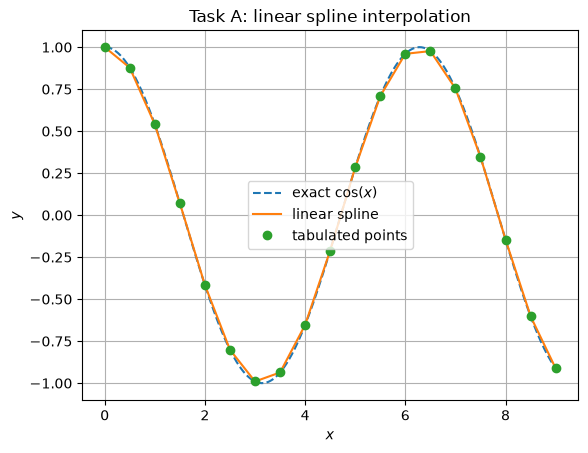

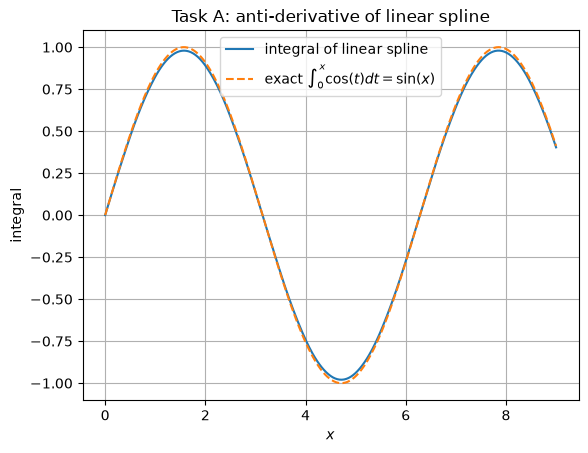

In [4]:
import numpy as np
import matplotlib.pyplot as plt

points = np.loadtxt("spline_A_points.data")
curves = np.loadtxt("spline_A_curves.data")

x = points[:, 0]
y = points[:, 1]

z = curves[:, 0]
interp = curves[:, 1]
integ = curves[:, 2]
exact_cos = curves[:, 3]
exact_sin = curves[:, 4]

plt.figure()
plt.plot(z, exact_cos, "--", label=r"exact $\cos(x)$")
plt.plot(z, interp, "-", label="linear spline")
plt.plot(x, y, "o", label="tabulated points")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Task A: linear spline interpolation")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(z, integ, "-", label="integral of linear spline")
plt.plot(z, exact_sin, "--", label=r"exact $\int_0^x \cos(t)dt=\sin(x)$")
plt.xlabel("$x$")
plt.ylabel("integral")
plt.title("Task A: anti-derivative of linear spline")
plt.grid(True)
plt.legend()
plt.show()

### Task A conclusion

The linear spline interpolation was implemented and tested on tabulated values of $\cos(x)$. The interpolation reproduces the tabulated points with a maximum node error of about $10^{-17}$, which is consistent with floating-point roundoff. The anti-derivative of the linear spline was also calculated analytically piece by piece. The integrated spline follows the exact integral $\sin(x)$ well, with a small deviation caused by the piecewise-linear approximation between the tabulated points.

Therefore, the linear spline and its integral work as intended.

## Task B: Quadratic spline


The file `spline.hpp` contains the actual C++ implementation of the spline routines. In Task A it only contained the linear interpolation functions. For Task B, the same header was extended so that it also contains the quadratic spline class `pp::qspline`.

This was done to keep the implementation collected in one reusable C++ header file. Then `spline_B.cpp` can simply include

```cpp
#include "spline.hpp"

Overwrites spline.hpp with Task A + Task B:

In [5]:
from pathlib import Path

Path("spline.hpp").write_text(r'''
#pragma once

#include <vector>
#include <cassert>
#include <cmath>
#include <algorithm>
#include <stdexcept>

namespace pp {

inline int binsearch(const std::vector<double>& x, double z) {
    assert(x.size() >= 2);
    assert(z >= x.front() && z <= x.back());

    int i = 0;
    int j = static_cast<int>(x.size()) - 1;

    while (j - i > 1) {
        int mid = (i + j) / 2;
        if (z > x[mid]) {
            i = mid;
        } else {
            j = mid;
        }
    }

    return i;
}

// ---------- Task A: linear spline ----------

inline double linterp(const std::vector<double>& x,
                      const std::vector<double>& y,
                      double z) {
    assert(x.size() == y.size());
    int i = binsearch(x, z);

    double dx = x[i + 1] - x[i];
    double dy = y[i + 1] - y[i];

    assert(dx > 0);

    return y[i] + dy / dx * (z - x[i]);
}

inline double linterp_integ(const std::vector<double>& x,
                            const std::vector<double>& y,
                            double z) {
    assert(x.size() == y.size());
    assert(z >= x.front() && z <= x.back());

    int iz = binsearch(x, z);
    double sum = 0.0;

    for (int i = 0; i < iz; ++i) {
        double dx = x[i + 1] - x[i];
        double dy = y[i + 1] - y[i];
        double p = dy / dx;

        sum += y[i] * dx + 0.5 * p * dx * dx;
    }

    double h = z - x[iz];
    double dx = x[iz + 1] - x[iz];
    double dy = y[iz + 1] - y[iz];
    double p = dy / dx;

    sum += y[iz] * h + 0.5 * p * h * h;

    return sum;
}

// ---------- Task B: quadratic spline ----------

class qspline {
private:
    std::vector<double> x_;
    std::vector<double> y_;
    std::vector<double> b_;
    std::vector<double> c_;

public:
    qspline(const std::vector<double>& x, const std::vector<double>& y)
        : x_(x), y_(y) {
        assert(x_.size() == y_.size());
        assert(x_.size() >= 2);

        int n = static_cast<int>(x_.size());
        int intervals = n - 1;

        for (int i = 0; i < intervals; ++i) {
            assert(x_[i + 1] > x_[i]);
        }

        b_.resize(intervals);
        c_.resize(intervals);

        std::vector<double> h(intervals);
        std::vector<double> p(intervals);

        for (int i = 0; i < intervals; ++i) {
            h[i] = x_[i + 1] - x_[i];
            p[i] = (y_[i + 1] - y_[i]) / h[i];
        }

        // With only one interval, quadratic spline reduces to linear interpolation.
        if (intervals == 1) {
            c_[0] = 0.0;
            b_[0] = p[0];
            return;
        }

        // Forward recursion from c[0] = 0.
        c_[0] = 0.0;
        for (int i = 0; i < intervals - 1; ++i) {
            c_[i + 1] = (p[i + 1] - p[i] - c_[i] * h[i]) / h[i + 1];
        }

        // Backward recursion, averaged as in the lecture note/book.
        c_[intervals - 1] *= 0.5;
        for (int i = intervals - 2; i >= 0; --i) {
            c_[i] = (p[i + 1] - p[i] - c_[i + 1] * h[i + 1]) / h[i];
        }

        for (int i = 0; i < intervals; ++i) {
            b_[i] = p[i] - c_[i] * h[i];
        }
    }

    double eval(double z) const {
        int i = binsearch(x_, z);
        double h = z - x_[i];

        return y_[i] + b_[i] * h + c_[i] * h * h;
    }

    double deriv(double z) const {
        int i = binsearch(x_, z);
        double h = z - x_[i];

        return b_[i] + 2.0 * c_[i] * h;
    }

    double integ(double z) const {
        assert(z >= x_.front() && z <= x_.back());

        int iz = binsearch(x_, z);
        double sum = 0.0;

        for (int i = 0; i < iz; ++i) {
            double h = x_[i + 1] - x_[i];
            sum += y_[i] * h + 0.5 * b_[i] * h * h + c_[i] * h * h * h / 3.0;
        }

        double h = z - x_[iz];
        sum += y_[iz] * h + 0.5 * b_[iz] * h * h + c_[iz] * h * h * h / 3.0;

        return sum;
    }

    const std::vector<double>& b() const { return b_; }
    const std::vector<double>& c() const { return c_; }
};

} // namespace pp
''')

print("Wrote spline.hpp with Task A and Task B")

Wrote spline.hpp with Task A and Task B


spline_B.cpp:

In [6]:
from pathlib import Path

Path("spline_B.cpp").write_text(r'''
#include "spline.hpp"

#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <iomanip>
#include <algorithm>
#include <functional>
#include <string>

double max_dense_error(const std::vector<double>& x,
                       const std::vector<double>& y,
                       std::function<double(double)> exact) {
    pp::qspline qs(x, y);

    double max_err = 0.0;
    int N = 1000;

    for (int k = 0; k <= N; ++k) {
        double z = x.front() + (x.back() - x.front()) * k / N;
        max_err = std::max(max_err, std::abs(qs.eval(z) - exact(z)));
    }

    return max_err;
}

int main() {
    std::cout << std::setprecision(8);

    std::cout << "Task B: quadratic spline\n";
    std::cout << "------------------------\n";

    // Test data: x = 0, 0.5, ..., 9 and y = cos(x)
    std::vector<double> x;
    std::vector<double> y;

    for (int i = 0; i <= 18; ++i) {
        double xi = 0.5 * i;
        x.push_back(xi);
        y.push_back(std::cos(xi));
    }

    pp::qspline qs(x, y);

    double max_node_err = 0.0;
    for (std::size_t i = 0; i < x.size(); ++i) {
        max_node_err = std::max(max_node_err, std::abs(qs.eval(x[i]) - y[i]));
    }

    double max_deriv_jump = 0.0;
    for (std::size_t i = 0; i + 2 < x.size(); ++i) {
        double h = x[i + 1] - x[i];
        double left_deriv = qs.b()[i] + 2.0 * qs.c()[i] * h;
        double right_deriv = qs.b()[i + 1];
        max_deriv_jump = std::max(max_deriv_jump, std::abs(left_deriv - right_deriv));
    }

    double spline_integral = qs.integ(x.back());
    double exact_integral = std::sin(x.back()) - std::sin(x.front());

    std::cout << "number of points = " << x.size() << "\n";
    std::cout << "max interpolation error at nodes = " << max_node_err << "\n";
    std::cout << "max derivative jump at inner nodes = " << max_deriv_jump << "\n";
    std::cout << "integral from x[0] to x[last] = " << spline_integral << "\n";
    std::cout << "exact integral of cos over same interval = " << exact_integral << "\n\n";

    // Simple debugging tests from the task hint.
    std::vector<double> xtest = {1, 2, 3, 4, 5};

    std::vector<double> y_const;
    std::vector<double> y_linear;
    std::vector<double> y_quad;

    for (double xi : xtest) {
        y_const.push_back(1.0);
        y_linear.push_back(xi);
        y_quad.push_back(xi * xi);
    }

    std::cout << "Debug tests:\n";
    std::cout << "max error for y = 1   : "
              << max_dense_error(xtest, y_const, [](double) { return 1.0; }) << "\n";
    std::cout << "max error for y = x   : "
              << max_dense_error(xtest, y_linear, [](double z) { return z; }) << "\n";
    std::cout << "max error for y = x^2 : "
              << max_dense_error(xtest, y_quad, [](double z) { return z * z; }) << "\n";

    // Write tabulated points.
    {
        std::ofstream out("spline_B_points.data");
        for (std::size_t i = 0; i < x.size(); ++i) {
            out << x[i] << " " << y[i] << "\n";
        }
    }

    // Write curve data:
    // z, exact cos(z), qspline, qspline derivative, exact derivative,
    // qspline integral, exact integral.
    {
        std::ofstream out("spline_B_curves.data");

        int N = 500;
        for (int k = 0; k <= N; ++k) {
            double z = x.front() + (x.back() - x.front()) * k / N;

            out << z << " "
                << std::cos(z) << " "
                << qs.eval(z) << " "
                << qs.deriv(z) << " "
                << -std::sin(z) << " "
                << qs.integ(z) << " "
                << std::sin(z) - std::sin(x.front()) << "\n";
        }
    }

    std::cout << "\nWrote spline_B_points.data\n";
    std::cout << "Wrote spline_B_curves.data\n";

    return 0;
}
''')

print("Wrote spline_B.cpp")

Wrote spline_B.cpp


In [7]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "spline_B.cpp",
    "-o",
    "spline_B"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./spline_B"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: quadratic spline
------------------------
number of points = 19
max interpolation error at nodes = 1.110223e-16
max derivative jump at inner nodes = 1.110223e-16
integral from x[0] to x[last] = 0.41226596
exact integral of cos over same interval = 0.41211849

Debug tests:
max error for y = 1   : 0
max error for y = x   : 0
max error for y = x^2 : 3.5527137e-15

Wrote spline_B_points.data
Wrote spline_B_curves.data




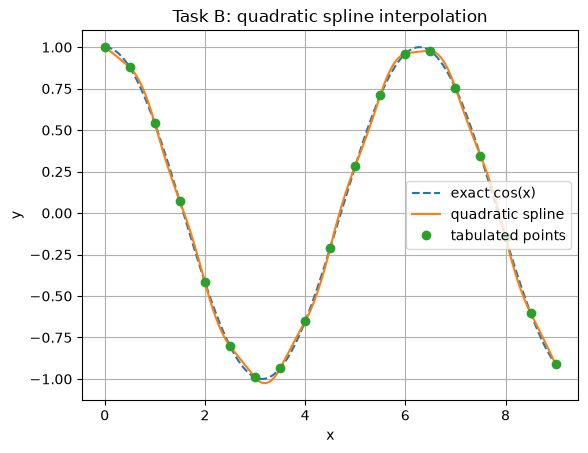

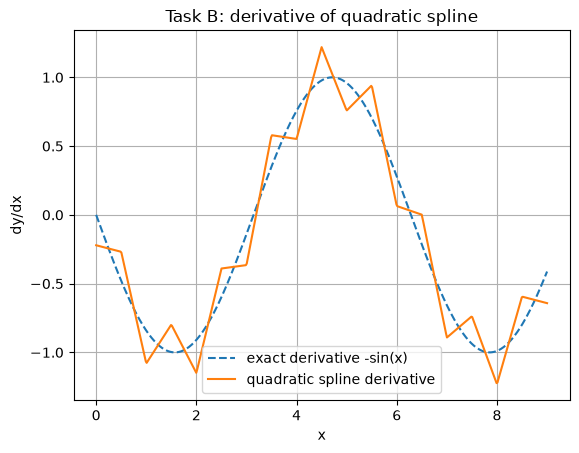

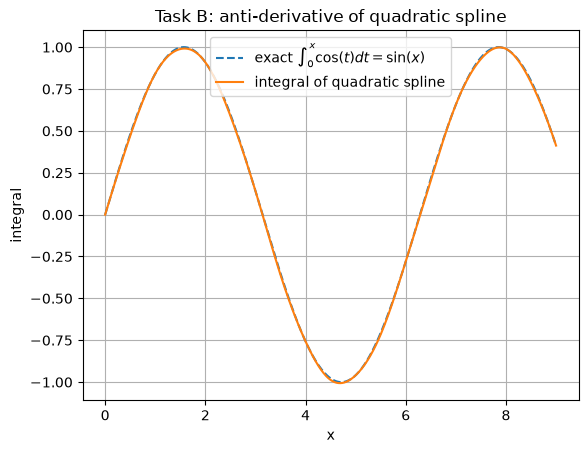

In [8]:
import numpy as np
import matplotlib.pyplot as plt

points = np.loadtxt("spline_B_points.data")
curves = np.loadtxt("spline_B_curves.data")

xp, yp = points[:, 0], points[:, 1]

z = curves[:, 0]
exact = curves[:, 1]
qs = curves[:, 2]
dqs = curves[:, 3]
dexact = curves[:, 4]
iqs = curves[:, 5]
iexact = curves[:, 6]

plt.figure()
plt.plot(z, exact, "--", label="exact cos(x)")
plt.plot(z, qs, label="quadratic spline")
plt.plot(xp, yp, "o", label="tabulated points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task B: quadratic spline interpolation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, dexact, "--", label="exact derivative -sin(x)")
plt.plot(z, dqs, label="quadratic spline derivative")
plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Task B: derivative of quadratic spline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, iexact, "--", label=r"exact $\int_0^x \cos(t)dt = \sin(x)$")
plt.plot(z, iqs, label="integral of quadratic spline")
plt.xlabel("x")
plt.ylabel("integral")
plt.title("Task B: anti-derivative of quadratic spline")
plt.legend()
plt.grid(True)
plt.show()


### Task B conclusion

A quadratic spline was implemented in C++ using an object-oriented style. The spline uses the local form

$$
s_i(x) = y_i + b_i(x-x_i) + c_i(x-x_i)^2
$$

on each interval. From this form, the value, derivative and integral of the spline can be evaluated directly.

The implementation was tested using tabulated values of

$$
y_i = \cos(x_i).
$$

The interpolation error at the tabulated points was about $10^{-16}$, which is consistent with numerical roundoff. The derivative jump at the inner nodes was also about $10^{-16}$, showing that the first derivative is continuous across the spline intervals.

The integral of the quadratic spline over the full interval was

$$
0.412266,
$$

while the exact integral of $\cos(x)$ over the same interval was

$$
0.412118.
$$

The agreement is very good. The derivative plot follows the general shape of the exact derivative $-\sin(x)$, but it is only piecewise linear because it comes from a quadratic spline. Therefore small deviations from the smooth exact derivative are expected.

Overall, the quadratic spline, its derivative and its definite integral work as intended.

## Task C

### C1: quadratic spline using functional programming style

In [9]:
from pathlib import Path

Path("spline_functional.hpp").write_text(r'''
#pragma once

#include "spline.hpp"

#include <vector>
#include <functional>
#include <tuple>
#include <cmath>
#include <cassert>
#include <utility>

namespace pp {

inline std::tuple<std::vector<double>, std::vector<double>>
qspline_coefficients(const std::vector<double>& x,
                     const std::vector<double>& y) {
    assert(x.size() == y.size());
    assert(x.size() >= 2);

    int n = static_cast<int>(x.size());
    int intervals = n - 1;

    std::vector<double> b(intervals);
    std::vector<double> c(intervals);
    std::vector<double> h(intervals);
    std::vector<double> p(intervals);

    for (int i = 0; i < intervals; ++i) {
        assert(x[i + 1] > x[i]);
        h[i] = x[i + 1] - x[i];
        p[i] = (y[i + 1] - y[i]) / h[i];
    }

    if (intervals == 1) {
        c[0] = 0.0;
        b[0] = p[0];
        return {b, c};
    }

    c[0] = 0.0;

    for (int i = 0; i < intervals - 1; ++i) {
        c[i + 1] = (p[i + 1] - p[i] - c[i] * h[i]) / h[i + 1];
    }

    c[intervals - 1] *= 0.5;

    for (int i = intervals - 2; i >= 0; --i) {
        c[i] = (p[i + 1] - p[i] - c[i + 1] * h[i + 1]) / h[i];
    }

    for (int i = 0; i < intervals; ++i) {
        b[i] = p[i] - c[i] * h[i];
    }

    return {b, c};
}

inline std::function<double(double)>
make_qspline_eval(std::vector<double> x, std::vector<double> y) {
    auto [b, c] = qspline_coefficients(x, y);

    return [x = std::move(x),
            y = std::move(y),
            b = std::move(b),
            c = std::move(c)](double z) {
        int i = binsearch(x, z);
        double h = z - x[i];

        return y[i] + b[i] * h + c[i] * h * h;
    };
}

inline std::function<double(double)>
make_qspline_deriv(std::vector<double> x, std::vector<double> y) {
    auto [b, c] = qspline_coefficients(x, y);

    return [x = std::move(x),
            b = std::move(b),
            c = std::move(c)](double z) {
        int i = binsearch(x, z);
        double h = z - x[i];

        return b[i] + 2.0 * c[i] * h;
    };
}

inline std::function<double(double)>
make_qspline_integ(std::vector<double> x, std::vector<double> y) {
    auto [b, c] = qspline_coefficients(x, y);

    return [x = std::move(x),
            y = std::move(y),
            b = std::move(b),
            c = std::move(c)](double z) {
        assert(z >= x.front() && z <= x.back());

        int iz = binsearch(x, z);
        double sum = 0.0;

        for (int i = 0; i < iz; ++i) {
            double h = x[i + 1] - x[i];
            sum += y[i] * h + 0.5 * b[i] * h * h + c[i] * h * h * h / 3.0;
        }

        double h = z - x[iz];
        sum += y[iz] * h + 0.5 * b[iz] * h * h + c[iz] * h * h * h / 3.0;

        return sum;
    };
}

} // namespace pp
''')

print("Wrote spline_functional.hpp")

Wrote spline_functional.hpp


In [10]:
from pathlib import Path

Path("spline_C.cpp").write_text(r'''
#include "spline_functional.hpp"

#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <iomanip>
#include <algorithm>

int main() {
    std::cout << std::setprecision(8);

    std::cout << "Task C: functional quadratic spline\n";
    std::cout << "-----------------------------------\n";

    std::vector<double> x;
    std::vector<double> y;

    for (int i = 0; i <= 18; ++i) {
        double xi = 0.5 * i;
        x.push_back(xi);
        y.push_back(std::cos(xi));
    }

    auto f  = pp::make_qspline_eval(x, y);
    auto df = pp::make_qspline_deriv(x, y);
    auto F  = pp::make_qspline_integ(x, y);

    double max_node_err = 0.0;

    for (std::size_t i = 0; i < x.size(); ++i) {
        max_node_err = std::max(max_node_err, std::abs(f(x[i]) - y[i]));
    }

    double spline_integral = F(x.back());
    double exact_integral = std::sin(x.back()) - std::sin(x.front());

    std::cout << "number of points = " << x.size() << "\n";
    std::cout << "max interpolation error at nodes = " << max_node_err << "\n";
    std::cout << "integral from x[0] to x[last] = " << spline_integral << "\n";
    std::cout << "exact integral of cos over same interval = " << exact_integral << "\n";

    std::ofstream points("spline_C_points.data");
    for (std::size_t i = 0; i < x.size(); ++i) {
        points << x[i] << " " << y[i] << "\n";
    }
    points.close();

    std::ofstream curves("spline_C_curves.data");

    int N = 500;
    for (int k = 0; k <= N; ++k) {
        double z = x.front() + (x.back() - x.front()) * k / N;

        curves << z << " "
               << std::cos(z) << " "
               << f(z) << " "
               << -std::sin(z) << " "
               << df(z) << " "
               << std::sin(z) << " "
               << F(z) << "\n";
    }

    curves.close();

    std::cout << "Wrote spline_C_points.data\n";
    std::cout << "Wrote spline_C_curves.data\n";

    return 0;
}
''')

print("Wrote spline_C.cpp")

Wrote spline_C.cpp


In [11]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "spline_C.cpp",
    "-o",
    "spline_C"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./spline_C"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C: functional quadratic spline
-----------------------------------
number of points = 19
max interpolation error at nodes = 1.110223e-16
integral from x[0] to x[last] = 0.41226596
exact integral of cos over same interval = 0.41211849
Wrote spline_C_points.data
Wrote spline_C_curves.data




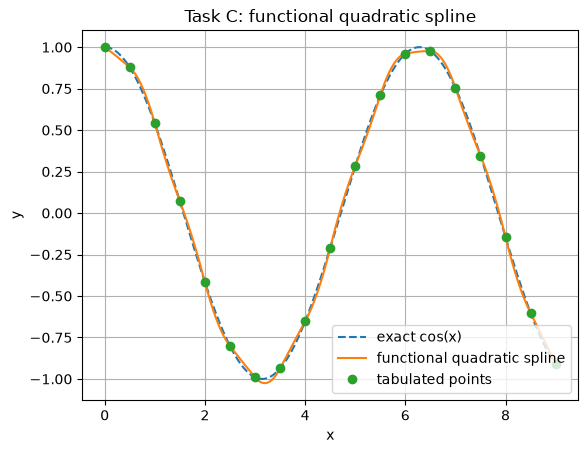

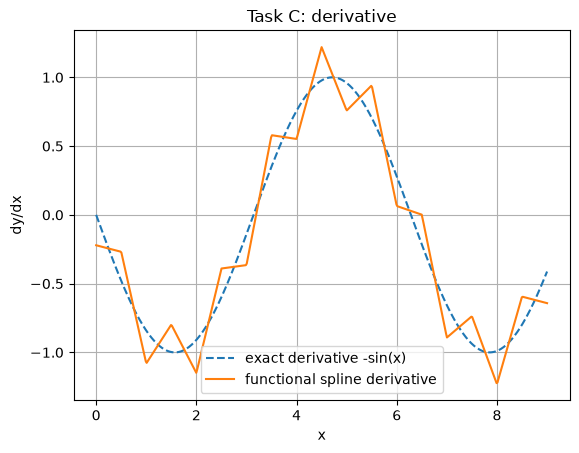

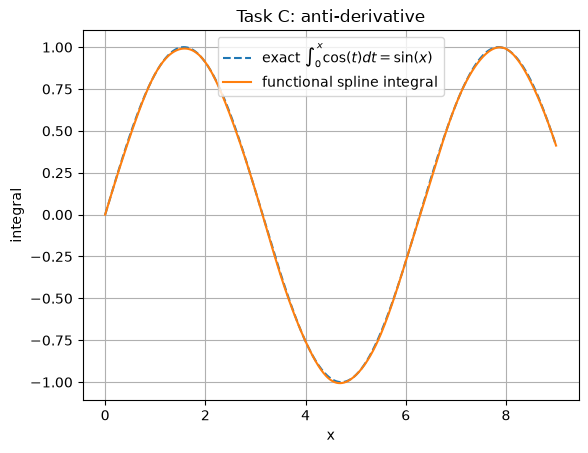

In [12]:
import numpy as np
import matplotlib.pyplot as plt

points = np.loadtxt("spline_C_points.data")
curves = np.loadtxt("spline_C_curves.data")

xp, yp = points[:, 0], points[:, 1]

z = curves[:, 0]
exact = curves[:, 1]
qs = curves[:, 2]
dexact = curves[:, 3]
dqs = curves[:, 4]
iexact = curves[:, 5]
iqs = curves[:, 6]

plt.figure()
plt.plot(z, exact, "--", label="exact cos(x)")
plt.plot(z, qs, label="functional quadratic spline")
plt.plot(xp, yp, "o", label="tabulated points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C: functional quadratic spline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, dexact, "--", label="exact derivative -sin(x)")
plt.plot(z, dqs, label="functional spline derivative")
plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Task C: derivative")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, iexact, "--", label=r"exact $\int_0^x \cos(t)dt = \sin(x)$")
plt.plot(z, iqs, label="functional spline integral")
plt.xlabel("x")
plt.ylabel("integral")
plt.title("Task C: anti-derivative")
plt.legend()
plt.grid(True)
plt.show()

### C2: cubic spline med derivative og definite integral

In [13]:
from pathlib import Path

Path("cubic_spline.hpp").write_text(r'''
#pragma once

#include "spline.hpp"

#include <vector>
#include <cassert>
#include <cmath>
#include <stdexcept>

namespace pp {

class cspline {
private:
    std::vector<double> x_;
    std::vector<double> y_;

    // Local cubic on interval i:
    // S_i(z) = y_i + b_i*h + c_i*h^2 + d_i*h^3,
    // where h = z - x_i.
    std::vector<double> b_;
    std::vector<double> c_;
    std::vector<double> d_;

public:
    cspline(const std::vector<double>& x, const std::vector<double>& y)
        : x_(x), y_(y) {
        assert(x_.size() == y_.size());
        assert(x_.size() >= 2);

        int n = static_cast<int>(x_.size());
        int intervals = n - 1;

        b_.resize(intervals);
        c_.resize(n);
        d_.resize(intervals);

        std::vector<double> h(intervals);
        std::vector<double> p(intervals);

        for (int i = 0; i < intervals; ++i) {
            assert(x_[i + 1] > x_[i]);
            h[i] = x_[i + 1] - x_[i];
            p[i] = (y_[i + 1] - y_[i]) / h[i];
        }

        // Natural cubic spline boundary conditions:
        // S''(x_0) = 0 and S''(x_{n-1}) = 0.
        c_[0] = 0.0;
        c_[n - 1] = 0.0;

        if (n == 2) {
            b_[0] = p[0];
            d_[0] = 0.0;
            return;
        }

        // Solve tridiagonal system for c[1],...,c[n-2].
        // c_i is half the second derivative at node i.
        int m = n - 2;

        std::vector<double> lower(m, 0.0);
        std::vector<double> diag(m, 0.0);
        std::vector<double> upper(m, 0.0);
        std::vector<double> rhs(m, 0.0);

        for (int i = 0; i < m; ++i) {
            int node = i + 1;

            lower[i] = h[node - 1];
            diag[i]  = 2.0 * (h[node - 1] + h[node]);
            upper[i] = h[node];
            rhs[i]   = 3.0 * (p[node] - p[node - 1]);
        }

        // Forward elimination.
        for (int i = 1; i < m; ++i) {
            double factor = lower[i] / diag[i - 1];
            diag[i] -= factor * upper[i - 1];
            rhs[i]  -= factor * rhs[i - 1];
        }

        // Back substitution.
        std::vector<double> sol(m, 0.0);

        sol[m - 1] = rhs[m - 1] / diag[m - 1];

        for (int i = m - 2; i >= 0; --i) {
            sol[i] = (rhs[i] - upper[i] * sol[i + 1]) / diag[i];
        }

        for (int i = 0; i < m; ++i) {
            c_[i + 1] = sol[i];
        }

        // Calculate b_i and d_i.
        for (int i = 0; i < intervals; ++i) {
            b_[i] = p[i] - h[i] * (2.0 * c_[i] + c_[i + 1]) / 3.0;
            d_[i] = (c_[i + 1] - c_[i]) / (3.0 * h[i]);
        }
    }

    double eval(double z) const {
        int i = binsearch(x_, z);
        double h = z - x_[i];

        return y_[i] + b_[i]*h + c_[i]*h*h + d_[i]*h*h*h;
    }

    double deriv(double z) const {
        int i = binsearch(x_, z);
        double h = z - x_[i];

        return b_[i] + 2.0*c_[i]*h + 3.0*d_[i]*h*h;
    }

    double integ(double z) const {
        assert(z >= x_.front() && z <= x_.back());

        int iz = binsearch(x_, z);
        double sum = 0.0;

        for (int i = 0; i < iz; ++i) {
            double h = x_[i + 1] - x_[i];
            sum += y_[i]*h
                 + 0.5*b_[i]*h*h
                 + c_[i]*h*h*h/3.0
                 + d_[i]*h*h*h*h/4.0;
        }

        double h = z - x_[iz];

        sum += y_[iz]*h
             + 0.5*b_[iz]*h*h
             + c_[iz]*h*h*h/3.0
             + d_[iz]*h*h*h*h/4.0;

        return sum;
    }

    double second_deriv(double z) const {
        int i = binsearch(x_, z);
        double h = z - x_[i];

        return 2.0*c_[i] + 6.0*d_[i]*h;
    }
};

} // namespace pp
''')

print("Wrote cubic_spline.hpp")

Wrote cubic_spline.hpp


In [14]:
from pathlib import Path

Path("spline_C_cubic.cpp").write_text(r'''
#include "cubic_spline.hpp"

#include <iostream>
#include <fstream>
#include <vector>
#include <cmath>
#include <iomanip>
#include <algorithm>

int main() {
    std::cout << std::setprecision(10);

    std::cout << "Task C2: cubic spline\n";
    std::cout << "---------------------\n";

    std::vector<double> x;
    std::vector<double> y;

    for (int i = 0; i <= 18; ++i) {
        double xi = 0.5 * i;
        x.push_back(xi);
        y.push_back(std::cos(xi));
    }

    pp::cspline cs(x, y);

    double max_node_err = 0.0;

    for (std::size_t i = 0; i < x.size(); ++i) {
        max_node_err = std::max(max_node_err, std::abs(cs.eval(x[i]) - y[i]));
    }

    double max_deriv_jump = 0.0;
    double max_second_deriv_jump = 0.0;

    for (std::size_t i = 1; i + 1 < x.size(); ++i) {
        double z = x[i];
        double eps = 1e-8;

        double left_d  = cs.deriv(z - eps);
        double right_d = cs.deriv(z + eps);

        double left_dd  = cs.second_deriv(z - eps);
        double right_dd = cs.second_deriv(z + eps);

        max_deriv_jump = std::max(max_deriv_jump, std::abs(left_d - right_d));
        max_second_deriv_jump = std::max(max_second_deriv_jump, std::abs(left_dd - right_dd));
    }

    double spline_integral = cs.integ(x.back());
    double exact_integral = std::sin(x.back()) - std::sin(x.front());

    std::cout << "number of points = " << x.size() << "\n";
    std::cout << "max interpolation error at nodes = " << max_node_err << "\n";
    std::cout << "max derivative jump at inner nodes = " << max_deriv_jump << "\n";
    std::cout << "max second derivative jump at inner nodes = " << max_second_deriv_jump << "\n";
    std::cout << "integral from x[0] to x[last] = " << spline_integral << "\n";
    std::cout << "exact integral of cos over same interval = " << exact_integral << "\n";

    {
        std::ofstream out("spline_C_cubic_points.data");

        for (std::size_t i = 0; i < x.size(); ++i) {
            out << x[i] << " " << y[i] << "\n";
        }
    }

    {
        std::ofstream out("spline_C_cubic_curves.data");

        int N = 800;

        for (int k = 0; k <= N; ++k) {
            double z = x.front() + (x.back() - x.front()) * k / N;

            out << z << " "
                << std::cos(z) << " "
                << cs.eval(z) << " "
                << -std::sin(z) << " "
                << cs.deriv(z) << " "
                << std::sin(z) << " "
                << cs.integ(z) << "\n";
        }
    }

    std::cout << "Wrote spline_C_cubic_points.data\n";
    std::cout << "Wrote spline_C_cubic_curves.data\n";

    return 0;
}
''')

print("Wrote spline_C_cubic.cpp")

Wrote spline_C_cubic.cpp


In [15]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "spline_C_cubic.cpp",
    "-o",
    "spline_C_cubic"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    run = subprocess.run(["./spline_C_cubic"], text=True, capture_output=True)
    print("Program output:")
    print(run.stdout)
    print(run.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task C2: cubic spline
---------------------
number of points = 19
max interpolation error at nodes = 1.110223025e-16
max derivative jump at inner nodes = 2.339181182e-08
max second derivative jump at inner nodes = 2.399877584e-08
integral from x[0] to x[last] = 0.4118065788
exact integral of cos over same interval = 0.4121184852
Wrote spline_C_cubic_points.data
Wrote spline_C_cubic_curves.data




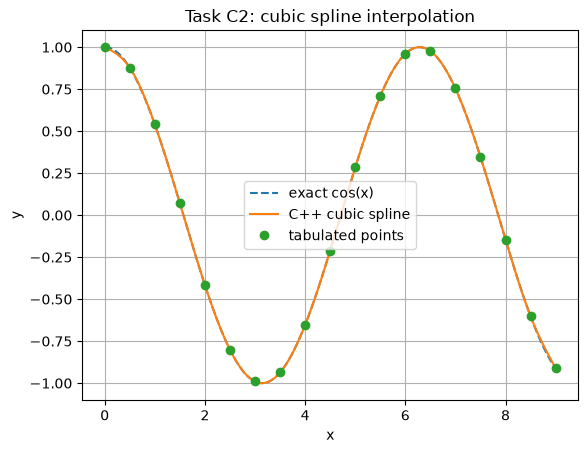

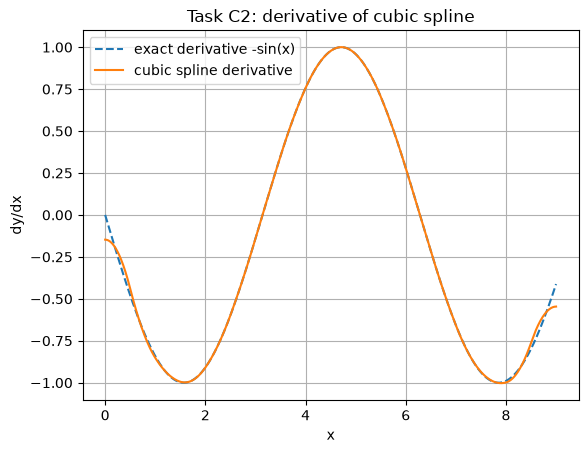

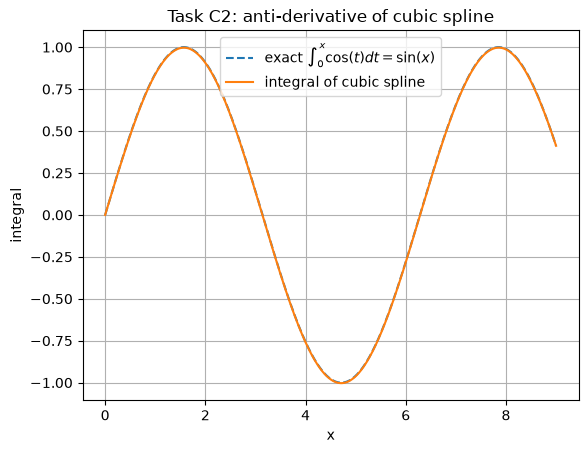

In [16]:
import numpy as np
import matplotlib.pyplot as plt

points = np.loadtxt("spline_C_cubic_points.data")
curves = np.loadtxt("spline_C_cubic_curves.data")

xp, yp = points[:, 0], points[:, 1]

z = curves[:, 0]
exact = curves[:, 1]
cs = curves[:, 2]
dexact = curves[:, 3]
dcs = curves[:, 4]
iexact = curves[:, 5]
ics = curves[:, 6]

plt.figure()
plt.plot(z, exact, "--", label="exact cos(x)")
plt.plot(z, cs, label="C++ cubic spline")
plt.plot(xp, yp, "o", label="tabulated points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Task C2: cubic spline interpolation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, dexact, "--", label="exact derivative -sin(x)")
plt.plot(z, dcs, label="cubic spline derivative")
plt.xlabel("x")
plt.ylabel("dy/dx")
plt.title("Task C2: derivative of cubic spline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(z, iexact, "--", label=r"exact $\int_0^x \cos(t)dt = \sin(x)$")
plt.plot(z, ics, label="integral of cubic spline")
plt.xlabel("x")
plt.ylabel("integral")
plt.title("Task C2: anti-derivative of cubic spline")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
from pathlib import Path

Path("gnuplot_cubic_compare.gp").write_text(r'''
set terminal pngcairo size 1000,700
set output "gnuplot_cubic_compare.png"

set title "Task C2: C++ cubic spline vs gnuplot smooth csplines"
set xlabel "x"
set ylabel "y"
set grid

plot \
    "spline_C_cubic_curves.data" using 1:3 with lines linewidth 2 title "C++ cubic spline", \
    "spline_C_cubic_points.data" using 1:2 smooth csplines with lines dashtype 2 linewidth 2 title "gnuplot smooth csplines", \
    "spline_C_cubic_points.data" using 1:2 with points pointtype 7 title "tabulated points"
''')

print("Wrote gnuplot_cubic_compare.gp")

Wrote gnuplot_cubic_compare.gp


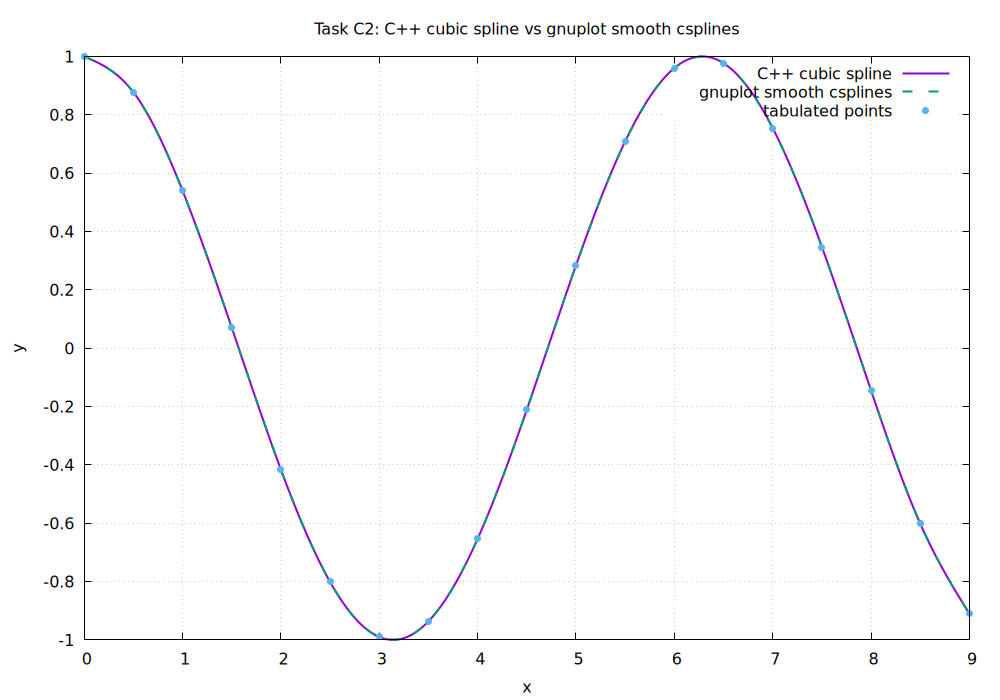

In [21]:
import subprocess
import shutil
from pathlib import Path
from IPython.display import Image, display

if shutil.which("gnuplot") is None:
    print("gnuplot is not installed.")
    print("Install it in the WSL terminal with:")
    print("sudo apt update")
    print("sudo apt install gnuplot-nox")
else:
    r = subprocess.run(
        ["gnuplot", "gnuplot_cubic_compare.gp"],
        text=True,
        capture_output=True
    )

    print(r.stdout)
    print(r.stderr)

    if Path("gnuplot_cubic_compare.png").exists():
        display(Image(filename="gnuplot_cubic_compare.png"))
    else:
        print("gnuplot did not produce the image.")

### Task C conclusion

In Task C, the quadratic spline was first implemented using a functional programming style. Instead of storing the spline in a class, the function returns callable functions which capture the required data vectors and spline coefficients. The functional quadratic spline gives the same numerical behaviour as the object-oriented version from Task B. It reproduces the tabulated points with an error of about $10^{-16}$ and gives an integral very close to the exact value for $\cos(x)$.

A cubic spline was also implemented in C++. On each interval, the spline has the form

$$
S_i(x) = y_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3.
$$

The implementation includes methods for evaluating the spline, its derivative and its definite integral. The cubic spline reproduces the tabulated points to numerical precision. The derivative and second derivative are continuous at the inner nodes up to small numerical errors of order $10^{-8}$.

The cubic spline follows $\cos(x)$ very closely, and its derivative follows the exact derivative $-\sin(x)$ much better than the quadratic spline derivative. The anti-derivative also agrees well with the exact integral $\sin(x)$.

Finally, the C++ cubic spline was compared with gnuplot's built-in `smooth csplines`. The two curves are almost identical, which confirms that the implementation behaves like a standard cubic spline routine.

Overall, both the functional quadratic spline and the cubic spline work as intended.

## Final conclusion

First, a linear spline was implemented using binary search to locate the correct interval. The linear spline reproduces the tabulated points exactly and gives a simple piecewise-linear approximation between them. Its definite integral was calculated analytically interval by interval and was shown to follow the exact integral of $\cos(x)$ reasonably well.

Next, a quadratic spline was implemented using an object-oriented style. The spline stores the tabulated data and the coefficients needed to evaluate the spline, its derivative and its integral. The quadratic spline reproduces the tabulated points to numerical precision, and the first derivative is continuous at the inner nodes. The derivative is piecewise linear, so it follows the general shape of the exact derivative but is less smooth than the cubic spline derivative.

Finally, Task C implemented the quadratic spline using a functional programming style and also implemented a cubic spline. The functional quadratic spline produced the same results as the object-oriented version, but with the spline data captured inside returned functions. The cubic spline gave a smoother interpolation and a much smoother derivative. It reproduced the data points to numerical precision and agreed very well with both the exact function and gnuplot's built-in cubic spline interpolation.

Overall, the linear, quadratic and cubic spline routines all work as intended. The results also show the expected improvement in smoothness when moving from linear to quadratic and then to cubic splines.